--- DISERTAȚIE: Isolation Forest cu PRAG DINAMIC ---
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.
Antrenare pe cpu finalizată în 1.04s

1. RAPORT FINAL DE AUDIT:
SISTEM AUDIT SSH - REZULTATE ISOLATION FOREST pe CPU
Scor AUC (Capacitate de discriminare): 0.6142
              precision    recall  f1-score   support

      Normal       0.90      0.68      0.77     86415
    Anomalie       0.20      0.51      0.29     13835

    accuracy                           0.65    100250
   macro avg       0.55      0.59      0.53    100250
weighted avg       0.80      0.65      0.70    100250


2. GENERARE MATRICE DE CONFUZIE...


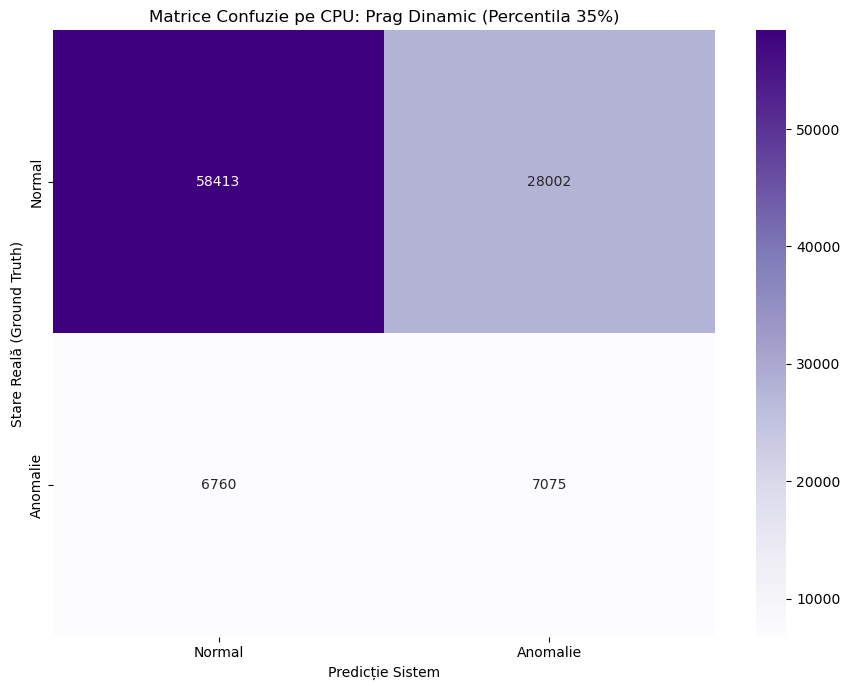


3. GENERARE CURBA ROC...


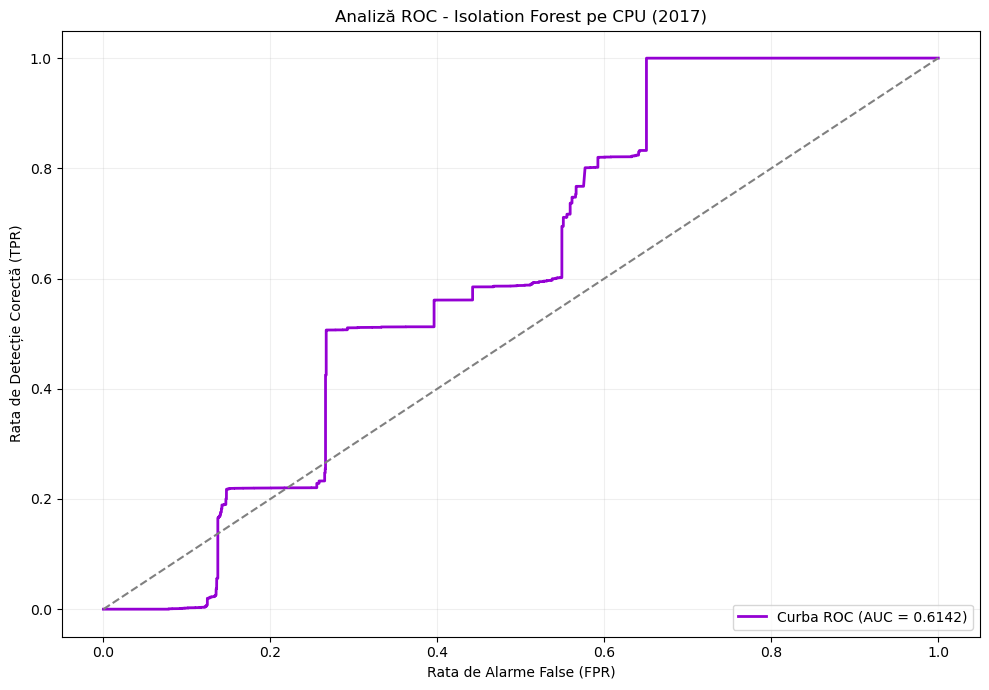


Toate rezultatele și modelul au fost salvate cu succes în: D:\disertatie\rezultate_2017\Isolation_Forest


In [1]:
import torch
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import time

prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\Isolation_Forest'
rezultate_path = r'D:\disertatie\rezultate_2017\Isolation_Forest'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- DISERTAȚIE: Isolation Forest cu PRAG DINAMIC ---")
X_train = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt')).numpy()
X_test = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt')).numpy()
y_test = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt')).numpy()
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test.shape[0]} rânduri.")
iso_forest = IsolationForest(
    n_estimators=100, 
    contamination=0.15, 
    random_state=42,
    max_samples=256, 
    n_jobs=-1
)

start_time = time.time()
iso_forest.fit(X_train)
print(f"Antrenare pe cpu finalizată în {time.time() - start_time:.2f}s")

decision_scores = iso_forest.decision_function(X_test)
percentila_dorita = 35
prag_dinamic = np.percentile(decision_scores, percentila_dorita)
y_pred = [1 if x < prag_dinamic else 0 for x in decision_scores]

y_scores = -decision_scores 
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
full_report_text = f"SISTEM AUDIT SSH - REZULTATE ISOLATION FOREST pe CPU\n"
full_report_text += f"Scor AUC (Capacitate de discriminare): {roc_auc:.4f}\n"
full_report_text += "="*50 + "\n"
full_report_text += report

print("\n1. RAPORT FINAL DE AUDIT:")
print(full_report_text)

with open(os.path.join(rezultate_path, 'raport_final_iso_forest_cpu.txt'), 'w') as f:
    f.write(full_report_text)

print("\n2. GENERARE MATRICE DE CONFUZIE...")
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title(f'Matrice Confuzie pe CPU: Prag Dinamic (Percentila {percentila_dorita}%)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_iso_forest_cpu.png'), dpi=300)
plt.show()

print("\n3. GENERARE CURBA ROC...")
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - Isolation Forest pe CPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_iso_forest_cpu.png'), dpi=300)
plt.show()

joblib.dump(iso_forest, os.path.join(model_save_path, 'model_iso_forest_dinamic_cpu.pkl'))
print(f"\nToate rezultatele și modelul au fost salvate cu succes în: {rezultate_path}")